In [22]:
DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patients = sorted(os.listdir(DATASET_PATH))

print("Nombre de patients :", len(patients))
print(patients[:5])
patient = patients[0]

print(os.listdir(os.path.join(DATASET_PATH, patient)))

Nombre de patients : 240
['sub-strokecase0001', 'sub-strokecase0002', 'sub-strokecase0003', 'sub-strokecase0004', 'sub-strokecase0006']
['flair.npy', 'adc.npy', 'dwi.npy', 'mask.npy']


In [23]:
import numpy as np
import os

DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patient = "sub-strokecase0001"
patient_path = os.path.join(DATASET_PATH, patient)

for file in ["flair.npy", "adc.npy", "dwi.npy", "mask.npy"]:
    data = np.load(os.path.join(patient_path, file))
    print(f"{file}")
    print(f"Shape : {data.shape}")
    print(f"Dtype : {data.dtype}")
    print("-" * 40)

flair.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
adc.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
dwi.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
mask.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------


## Import Libraries

In [24]:
!pip install -q monai nibabel SimpleITK

In [25]:
# installation mlflow
!pip install -q mlflow

In [26]:
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU
from monai.transforms import Compose, Activations, AsDiscrete, RandFlipd, RandRotate90d
from monai.data import decollate_batch

In [27]:
MLFLOW_TRACKING_URI = "https://elated-autistic-subfloor.ngrok-free.dev"
EXPERIMENT_NAME = "Stroke-Segmentation"

In [28]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    client = mlflow.MlflowClient()
    client.search_experiments()  # ping simple pour tester la connexion
    print(f"Connexion réussie au serveur MLflow : {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"Impossible de se connecter au serveur MLflow ({MLFLOW_TRACKING_URI})")
    print(f"Erreur : {e}")

mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment actif : {EXPERIMENT_NAME}")

Connexion réussie au serveur MLflow : https://elated-autistic-subfloor.ngrok-free.dev
Experiment actif : Stroke-Segmentation


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"PyTorch Version : {torch.__version__}")
print(f"MONAI Version   : {__import__('monai').__version__}")
print(f"Device          : {device}")
print("=" * 50)

PyTorch Version : 2.10.0+cu128
MONAI Version   : 1.6.0
Device          : cuda


# Experiment 1: 2D U-Net for Stroke Lesion Segmentation Using the FLAIR Modality

### Project Configuration

In [30]:
from pathlib import Path
import random
import numpy as np
import torch
DATASET_PATH = Path("/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed")
BATCH_SIZE = 16
NUM_EPOCHS = 100
NUM_WORKERS = 2
MODALITY = "flair"
NUM_CHANNELS = 1
experiments = [
    {"name": "FLAIR_2D_Adam_lr1e3", "optimizer": Adam, "lr": 1e-3},
    {"name": "FLAIR_2D_Adam_lr5e4_FLAIR", "optimizer": Adam, "lr": 5e-4}
]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = Path("/kaggle/working/models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Project Configuration")
print(f"Dataset Path : {DATASET_PATH}")
print(f"Modality     : {MODALITY.upper()}")
print(f"Channels     : {NUM_CHANNELS}")
print(f"Device       : {DEVICE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Workers      : {NUM_WORKERS}")
print(f"Experiments  : {len(experiments)}")
print(f"Save Dir     : {SAVE_DIR}")
for exp in experiments:
    print(f"{exp['name']} | LR = {exp['lr']}")

Project Configuration
Dataset Path : /kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed
Modality     : FLAIR
Channels     : 1
Device       : cuda
Batch Size   : 16
Epochs       : 100
Workers      : 2
Experiments  : 2
Save Dir     : /kaggle/working/models
FLAIR_2D_Adam_lr1e3 | LR = 0.001
FLAIR_2D_Adam_lr5e4_FLAIR | LR = 0.0005


### Train / Validation / Test Split

In [31]:
# Get all patient folders
patients = sorted(
    [
        patient.name
        for patient in DATASET_PATH.iterdir()
        if patient.is_dir()
    ]
)

print(f"Total Patients : {len(patients)}")


train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

# Convert patient names to full paths

train_patients = [
    DATASET_PATH / p
    for p in train_patients
]

val_patients = [
    DATASET_PATH / p
    for p in val_patients
]

test_patients = [
    DATASET_PATH / p
    for p in test_patients
]


print("\nDataset Split")
print("-" * 40)

print(
    f"Train      : {len(train_patients):3d} patients "
    f"({len(train_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Validation : {len(val_patients):3d} patients "
    f"({len(val_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Test       : {len(test_patients):3d} patients "
    f"({len(test_patients)/len(patients)*100:.1f}%)"
)

Total Patients : 240

Dataset Split
----------------------------------------
Train      : 168 patients (70.0%)
Validation :  36 patients (15.0%)
Test       :  36 patients (15.0%)


### Data Augmentation / Transforms

In [32]:
from monai.transforms import (
    Compose,
    RandFlipd,
    RandRotate90d
)

train_transform = Compose([

    # Random horizontal flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=0
    ),

    # Random vertical flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=1
    ),

    # Random 90-degree rotation
    RandRotate90d(
        keys=["image", "mask"],
        prob=0.5,
        max_k=3
    )
])

print("Training data augmentation configured.")

Training data augmentation configured.


### Création du StrokeDataset

In [33]:
class StrokeDataset2D(Dataset):

    def __init__(self, patient_dirs, transform=None):

        self.samples = []
        self.transform = transform

        # ----------------------------------------------------
        # Build the list of all 2D slices
        # ----------------------------------------------------

        for patient_dir in patient_dirs:

            # Load FLAIR only to determine number of slices
            flair = np.load(
                patient_dir / "flair.npy",
                mmap_mode="r"
            )

            num_slices = flair.shape[-1]

            for slice_idx in range(num_slices):

                self.samples.append(
                    (patient_dir, slice_idx)
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        patient_dir, slice_idx = self.samples[index]

        # ----------------------------------------------------
        # Load FLAIR volume and mask
        # ----------------------------------------------------

        flair = np.load(
            patient_dir / "flair.npy",
            mmap_mode="r"
        ).astype(np.float32)

        mask = np.load(
            patient_dir / "mask.npy",
            mmap_mode="r"
        ).astype(np.float32)

        # ----------------------------------------------------
        # Extract the same 2D slice
        # ----------------------------------------------------

        image = flair[:, :, slice_idx]
        target = mask[:, :, slice_idx]

        # ----------------------------------------------------
        # Z-score Normalization
        # ----------------------------------------------------

        mean = image.mean()
        std = image.std()

        if std > 0:
            image = (image - mean) / std

        image = np.expand_dims(
            image,
            axis=0
        )

        target = np.expand_dims(
            target,
            axis=0
        )

        image = torch.from_numpy(image).float()
        target = torch.from_numpy(target).float()

        if self.transform is not None:

            data = {
                "image": image,
                "mask": target
            }

            data = self.transform(data)

            image = data["image"]
            target = data["mask"]

        return image, target

### Créer dataset et les DataLoader

In [34]:
# Create Datasets

# Training dataset WITH data augmentation
train_dataset = StrokeDataset2D(
    train_patients,
    transform=train_transform
)

# Validation dataset WITHOUT data augmentation
val_dataset = StrokeDataset2D(
    val_patients,
    transform=None
)

# Test dataset WITHOUT data augmentation
test_dataset = StrokeDataset2D(
    test_patients,
    transform=None
)

# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print(f"Training slices   : {len(train_dataset)}")
print(f"Validation slices : {len(val_dataset)}")
print(f"Test slices       : {len(test_dataset)}")

print()

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

print("=" * 60)

Dataset Statistics
Training slices   : 10752
Validation slices : 2304
Test slices       : 2304

Train batches      : 672
Validation batches : 144
Test batches       : 144


In [35]:
images, masks = next(iter(train_loader))

print("Image shape :", images.shape)
print("Mask shape  :", masks.shape)

Image shape : torch.Size([16, 1, 128, 128])
Mask shape  : torch.Size([16, 1, 128, 128])


### Définir la Loss et l'Optimizer et Hyperparameters

In [36]:
# Loss Function

loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean",
    lambda_ce=0.5,
    lambda_dice=1.5
)

# Evaluation Metrics

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

iou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)

# Display Configuration

print("=" * 60)
print("Loss Function and Evaluation Metrics")
print("=" * 60)

print("\nLoss Function")
print(loss_function)

print("\nEvaluation Metrics")
print("- Dice Score")
print("- Mean IoU")

print("\nExperiments")

for exp in experiments:
    print(
        f"{exp['name']} | LR = {exp['lr']}"
    )

print("=" * 60)

Loss Function and Evaluation Metrics

Loss Function
DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)

Evaluation Metrics
- Dice Score
- Mean IoU

Experiments
FLAIR_2D_Adam_lr1e3 | LR = 0.001
FLAIR_2D_Adam_lr5e4_FLAIR | LR = 0.0005


In [37]:
# Post-processing for predictions

post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5)
])

### Fonction d'entraînement

In [38]:
def train_one_epoch(
    model,
    train_loader,
    optimizer,
    loss_function,
    device
):

    # Set model to training mode
    model.train()

    # Initialize cumulative loss
    epoch_loss = 0.0

    # Iterate over training batches
    for images, masks in train_loader:

        # Move data to device
        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = loss_function(
            outputs,
            masks
        )

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate batch loss
        epoch_loss += loss.item()

    # Compute average loss
    epoch_loss /= len(train_loader)

    return epoch_loss

### Fonction de validation

In [39]:
def validate(
    model,
    val_loader,
    dice_metric,
    iou_metric,
    post_pred,
    device
):

    # Set model to evaluation mode
    model.eval()

    # Reset metrics
    dice_metric.reset()
    iou_metric.reset()

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over validation batches
        for images, masks in val_loader:

            # Move data to device
            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            # Forward pass
            outputs = model(images)

            # Post-processing:
            # logits -> sigmoid -> binary mask
            outputs = [
                post_pred(pred)
                for pred in decollate_batch(outputs)
            ]

            # Convert ground truth batch to list
            masks = decollate_batch(masks)

            # Update Dice metric
            dice_metric(
                y_pred=outputs,
                y=masks
            )

            # Update IoU metric
            iou_metric(
                y_pred=outputs,
                y=masks
            )

    # Aggregate metrics
    dice = dice_metric.aggregate().item()
    iou = iou_metric.aggregate().item()

    # Reset metrics
    dice_metric.reset()
    iou_metric.reset()

    return dice, iou

### Entrainement


In [40]:
results = []
FLAIR_SAVE_DIR = SAVE_DIR / "flair"
FLAIR_SAVE_DIR.mkdir(parents=True, exist_ok=True)
for exp in experiments:
    run_name = exp["name"]
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("experiment_group", "FLAIR-2D")
        mlflow.set_tag("modality", "FLAIR")
        mlflow.set_tag("dimension", "2D")
        mlflow.set_tag("dataset", "ISLES2022")
        mlflow.set_tag("framework", "PyTorch + MONAI")
        mlflow.set_tag("task", "ischemic_stroke_lesion_segmentation")
        mlflow.log_params({
            "architecture": "U-Net",
            "model": "MONAI UNet",
            "spatial_dims": 2,
            "in_channels": NUM_CHANNELS,
            "out_channels": 1,
            "channels": str((16, 32, 64, 128, 256)),
            "strides": str((2, 2, 2, 2)),
            "num_res_units": 2,
            "optimizer": exp["optimizer"].__name__,
            "learning_rate": exp["lr"],
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "num_workers": NUM_WORKERS,
            "scheduler": "CosineAnnealingLR",
            "loss_function": "DiceCELoss",
            "loss_lambda_ce": 0.5,
            "loss_lambda_dice": 1.5,
            "dice_include_background": False,
            "iou_include_background": False,
            "augmentation": "RandFlipd + RandRotate90d",
            "seed": SEED
        })
        print("\n" + "=" * 60)
        print(f"Experiment: {run_name}")
        print(f"MLflow Run ID: {run.info.run_id}")
        print("=" * 60)
        model = UNet(
            spatial_dims=2,
            in_channels=NUM_CHANNELS,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2
        ).to(DEVICE)
        optimizer = exp["optimizer"](
            model.parameters(),
            lr=exp["lr"]
        )
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS
        )
        best_dice = 0.0
        best_iou = 0.0
        best_epoch = 0
        train_losses = []
        val_dices = []
        val_ious = []
        model_path = FLAIR_SAVE_DIR / f"best_model_{exp['name']}.pth"
        for epoch in range(NUM_EPOCHS):
            epoch_loss = train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                loss_function=loss_function,
                device=DEVICE
            )
            train_losses.append(epoch_loss)
            dice, iou = validate(
                model=model,
                val_loader=val_loader,
                dice_metric=dice_metric,
                iou_metric=iou_metric,
                post_pred=post_pred,
                device=DEVICE
            )
            val_dices.append(dice)
            val_ious.append(iou)
            scheduler.step()
            mlflow.log_metric("train_loss", epoch_loss, step=epoch + 1)
            mlflow.log_metric("val_dice", dice, step=epoch + 1)
            mlflow.log_metric("val_iou", iou, step=epoch + 1)
            if dice > best_dice:
                best_dice = dice
                best_iou = iou
                best_epoch = epoch + 1
                torch.save(
                    model.state_dict(),
                    model_path
                )
            print(
                f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f}"
            )
        mlflow.log_metric("best_dice", best_dice)
        mlflow.log_metric("best_iou", best_iou)
        mlflow.log_metric("best_epoch", best_epoch)
        mlflow.log_artifact(
            str(model_path),
            artifact_path="model"
        )
        curve_dir = SAVE_DIR / "mlflow_curves"
        curve_dir.mkdir(parents=True, exist_ok=True)
        curve_path = curve_dir / f"training_curves_{exp['name']}.png"
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        epochs = range(1, NUM_EPOCHS + 1)
        axes[0].plot(epochs, train_losses)
        axes[0].set_title("Training Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True)
        axes[1].plot(epochs, val_dices)
        axes[1].set_title("Validation Dice")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Dice")
        axes[1].set_ylim(0, 1)
        axes[1].grid(True)
        axes[2].plot(epochs, val_ious)
        axes[2].set_title("Validation IoU")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("IoU")
        axes[2].set_ylim(0, 1)
        axes[2].grid(True)
        plt.tight_layout()
        plt.savefig(curve_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(
            str(curve_path),
            artifact_path="plots"
        )
        run_id = run.info.run_id
        results.append({
            "Experiment": run_name,
            "Run Name": run_name,
            "MLflow Run ID": run_id,
            "Learning Rate": exp["lr"],
            "Best Dice": best_dice,
            "Best IoU": best_iou,
            "Best Epoch": best_epoch,
            "Train Loss": train_losses,
            "Validation Dice": val_dices,
            "Validation IoU": val_ious,
            "Model Path": str(model_path)
        })
        print(
            f"[FIN] {run_name} | Best Dice: {best_dice:.4f} | "
            f"Best IoU: {best_iou:.4f} | Best Epoch: {best_epoch} | "
            f"MLflow Run ID: {run_id}"
        )
print("\nTraining completed successfully.")


Experiment: FLAIR_2D_Adam_lr1e3
MLflow Run ID: 07484ad364014bfa9a2f44e213a1a5c2
Epoch [001/100] | Loss: 1.7367 | Dice: 0.3073 | IoU: 0.2185
Epoch [002/100] | Loss: 1.5200 | Dice: 0.4039 | IoU: 0.3055
Epoch [003/100] | Loss: 1.3407 | Dice: 0.4079 | IoU: 0.3082
Epoch [004/100] | Loss: 1.3231 | Dice: 0.3965 | IoU: 0.2972
Epoch [005/100] | Loss: 1.3184 | Dice: 0.4096 | IoU: 0.3098
Epoch [006/100] | Loss: 1.3108 | Dice: 0.4203 | IoU: 0.3164
Epoch [007/100] | Loss: 1.3068 | Dice: 0.4360 | IoU: 0.3351
Epoch [008/100] | Loss: 1.3034 | Dice: 0.4283 | IoU: 0.3277
Epoch [009/100] | Loss: 1.2998 | Dice: 0.4400 | IoU: 0.3374
Epoch [010/100] | Loss: 1.2978 | Dice: 0.4307 | IoU: 0.3299
Epoch [011/100] | Loss: 1.2938 | Dice: 0.4271 | IoU: 0.3244
Epoch [012/100] | Loss: 1.2919 | Dice: 0.4192 | IoU: 0.3184
Epoch [013/100] | Loss: 1.2891 | Dice: 0.4361 | IoU: 0.3351
Epoch [014/100] | Loss: 1.2858 | Dice: 0.4305 | IoU: 0.3272
Epoch [015/100] | Loss: 1.1749 | Dice: 0.0000 | IoU: 0.0000
Epoch [016/100] | L

### Comparaison des expériences

In [41]:
import pandas as pd
df_results = pd.DataFrame(results)
comparison_columns = [
    "Run Name",
    "MLflow Run ID",
    "Learning Rate",
    "Best Dice",
    "Best IoU",
    "Best Epoch",
    "Model Path"
]
df_comparison = df_results[comparison_columns].sort_values(
    by="Best Dice",
    ascending=False
).reset_index(drop=True)
print("Comparison of Experiments")
display(df_comparison)

Comparison of Experiments


,Run Name,MLflow Run ID,Learning Rate,Best Dice,Best IoU,Best Epoch,Model Path
0,FLAIR_2D_Adam_lr1e3,07484ad364014bfa9a2f44e213a1a5c2,0.0010,0.439988,0.337353,9,/kaggle/working/models/flair/best_model_FLAIR_...
1,FLAIR_2D_Adam_lr5e4_FLAIR,da0de4382f2d4c258f50efeca34bd941,0.0005,0.439177,0.339053,22,/kaggle/working/models/flair/best_model_FLAIR_...


### Tracer les courbes de Loss et du Dice

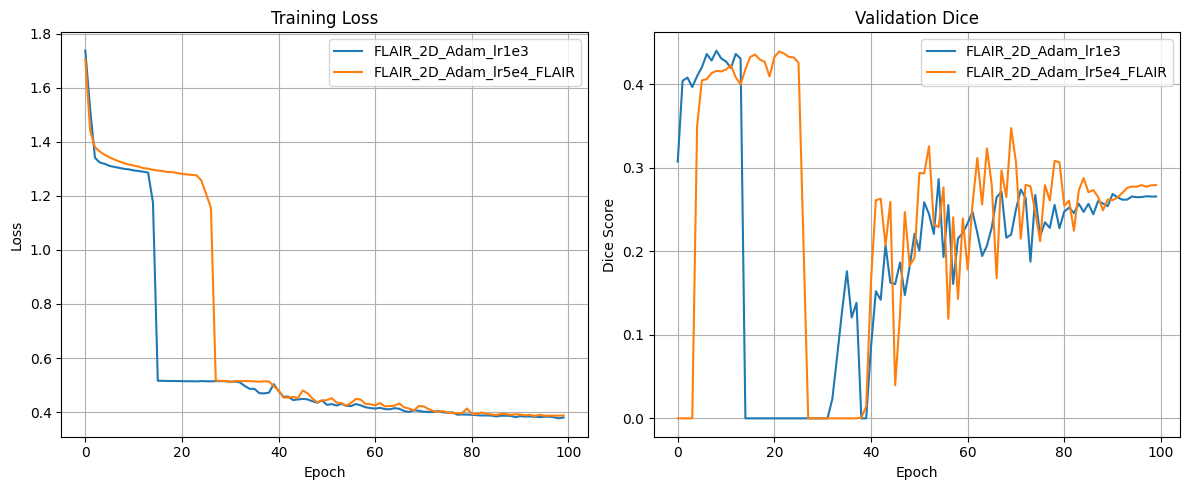

In [42]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)

for result in results:
    plt.plot(
        result["Train Loss"],
        label=result["Experiment"]
    )

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

for result in results:
    plt.plot(
        result["Validation Dice"],
        label=result["Experiment"]
    )

plt.title("Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Visualiser la prédiction du meilleur modèle

In [43]:
best_result = max(results, key=lambda x: x["Best Dice"])
print("Best Experiment :", best_result["Experiment"])
print("Best Dice       :", f"{best_result['Best Dice']:.4f}")
print("Best IoU        :", f"{best_result['Best IoU']:.4f}")
print("Best Epoch      :", best_result["Best Epoch"])
print("Model Path      :", best_result["Model Path"])
print("MLflow Run ID   :", best_result["MLflow Run ID"])
model = UNet(
    spatial_dims=2,
    in_channels=NUM_CHANNELS,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
).to(DEVICE)
model.load_state_dict(
    torch.load(
        best_result["Model Path"],
        map_location=DEVICE
    )
)
model.eval()
print("Best FLAIR model loaded successfully.")

Best Experiment : FLAIR_2D_Adam_lr1e3
Best Dice       : 0.4400
Best IoU        : 0.3374
Best Epoch      : 9
Model Path      : /kaggle/working/models/flair/best_model_FLAIR_2D_Adam_lr1e3.pth
MLflow Run ID   : 07484ad364014bfa9a2f44e213a1a5c2
Best FLAIR model loaded successfully.


### Evaluate on the Test Set

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
model.eval()
dice_metric.reset()
iou_metric.reset()
all_predictions = []
all_masks = []
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        dice_metric(y_pred=preds, y=masks)
        iou_metric(y_pred=preds, y=masks)
        all_predictions.append(preds.cpu().numpy().ravel())
        all_masks.append(masks.cpu().numpy().ravel())
dice = dice_metric.aggregate().item()
iou = iou_metric.aggregate().item()
dice_metric.reset()
iou_metric.reset()
all_predictions = np.concatenate(all_predictions).astype(np.uint8)
all_masks = np.concatenate(all_masks).astype(np.uint8)
precision = precision_score(all_masks, all_predictions, zero_division=0)
recall = recall_score(all_masks, all_predictions, zero_division=0)
f1 = f1_score(all_masks, all_predictions, zero_division=0)
cm = confusion_matrix(all_masks, all_predictions, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
results_metrics = pd.DataFrame({
    "Metric": ["Dice", "IoU", "Precision", "Recall", "F1-score"],
    "Value": [dice, iou, precision, recall, f1]
})
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_metric("test_dice", dice)
    mlflow.log_metric("test_iou", iou)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_f1", f1)
    mlflow.set_tag("evaluation_status", "test_evaluated")
print("U-Net 2D FLAIR - Test Set Performance")
display(results_metrics)
print("\nConfusion Matrix")
print(cm)
print("\nPixel Classification")
print(f"TP : {tp}")
print(f"TN : {tn}")
print(f"FP : {fp}")
print(f"FN : {fn}")

🏃 View run FLAIR_2D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/07484ad364014bfa9a2f44e213a1a5c2
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
U-Net 2D FLAIR - Test Set Performance


,Metric,Value
0,Dice,0.407797
1,IoU,0.305026
2,Precision,0.514926
3,Recall,0.548541
4,F1-score,0.531202



Confusion Matrix
[[37362495   131589]
 [  114965   139687]]

Pixel Classification
TP : 139687
TN : 37362495
FP : 131589
FN : 114965


### Evaluation Charts

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

evaluation_dir = SAVE_DIR / "mlflow_evaluation"
evaluation_dir.mkdir(parents=True, exist_ok=True)

test_metrics_path = evaluation_dir / "test_metrics.png"
confusion_matrix_path = evaluation_dir / "confusion_matrix.png"

# =========================
# Test Metrics Figure
# =========================
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    results_metrics["Metric"],
    results_metrics["Value"]
)

ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("FLAIR Model - Test Metrics")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.3f}",
        ha="center"
    )

ax.grid(axis="y")

plt.tight_layout()
plt.savefig(
    test_metrics_path,
    dpi=150,
    bbox_inches="tight"
)
plt.close(fig)


# =========================
# Confusion Matrix
# =========================
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Stroke"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title("Confusion Matrix - FLAIR Model")

plt.tight_layout()
plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)
plt.close(fig)


# =========================
# Log Artifacts to MLflow
# =========================
with mlflow.start_run(
    run_id=best_result["MLflow Run ID"]
):
    mlflow.log_artifact(
        str(test_metrics_path),
        artifact_path="evaluation"
    )

    mlflow.log_artifact(
        str(confusion_matrix_path),
        artifact_path="evaluation"
    )

print("Evaluation artifacts saved and logged to the Best Run.")

🏃 View run FLAIR_2D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/07484ad364014bfa9a2f44e213a1a5c2
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Evaluation artifacts saved and logged to the Best Run.


### Confusion Matrix

Confusion Matrix - FLAIR
[[37362495   131589]
 [  114965   139687]]

True Negatives (TN) : 37362495
False Positives (FP): 131589
False Negatives (FN): 114965
True Positives (TP) : 139687


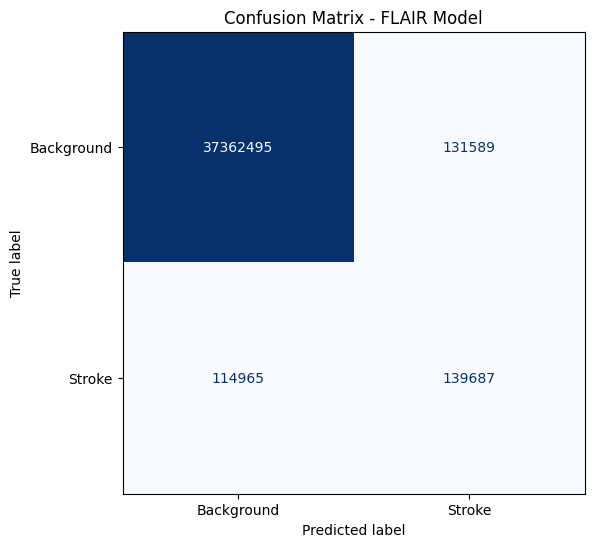

In [47]:
# ==========================================================
# Confusion Matrix - FLAIR Experiment
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        all_predictions.extend(
            predictions.cpu().numpy().flatten().astype(np.uint8)
        )

        all_targets.extend(
            masks.cpu().numpy().flatten().astype(np.uint8)
        )

# ----------------------------------------------------------
# Compute Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(
    all_targets,
    all_predictions
)

tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("Confusion Matrix - FLAIR")
print("=" * 60)

print(cm)

print(f"\nTrue Negatives (TN) : {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP) : {tp}")

# ----------------------------------------------------------
# Plot Confusion Matrix
# ----------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Stroke"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - FLAIR Model")

plt.show()

### Display Segmentation Results

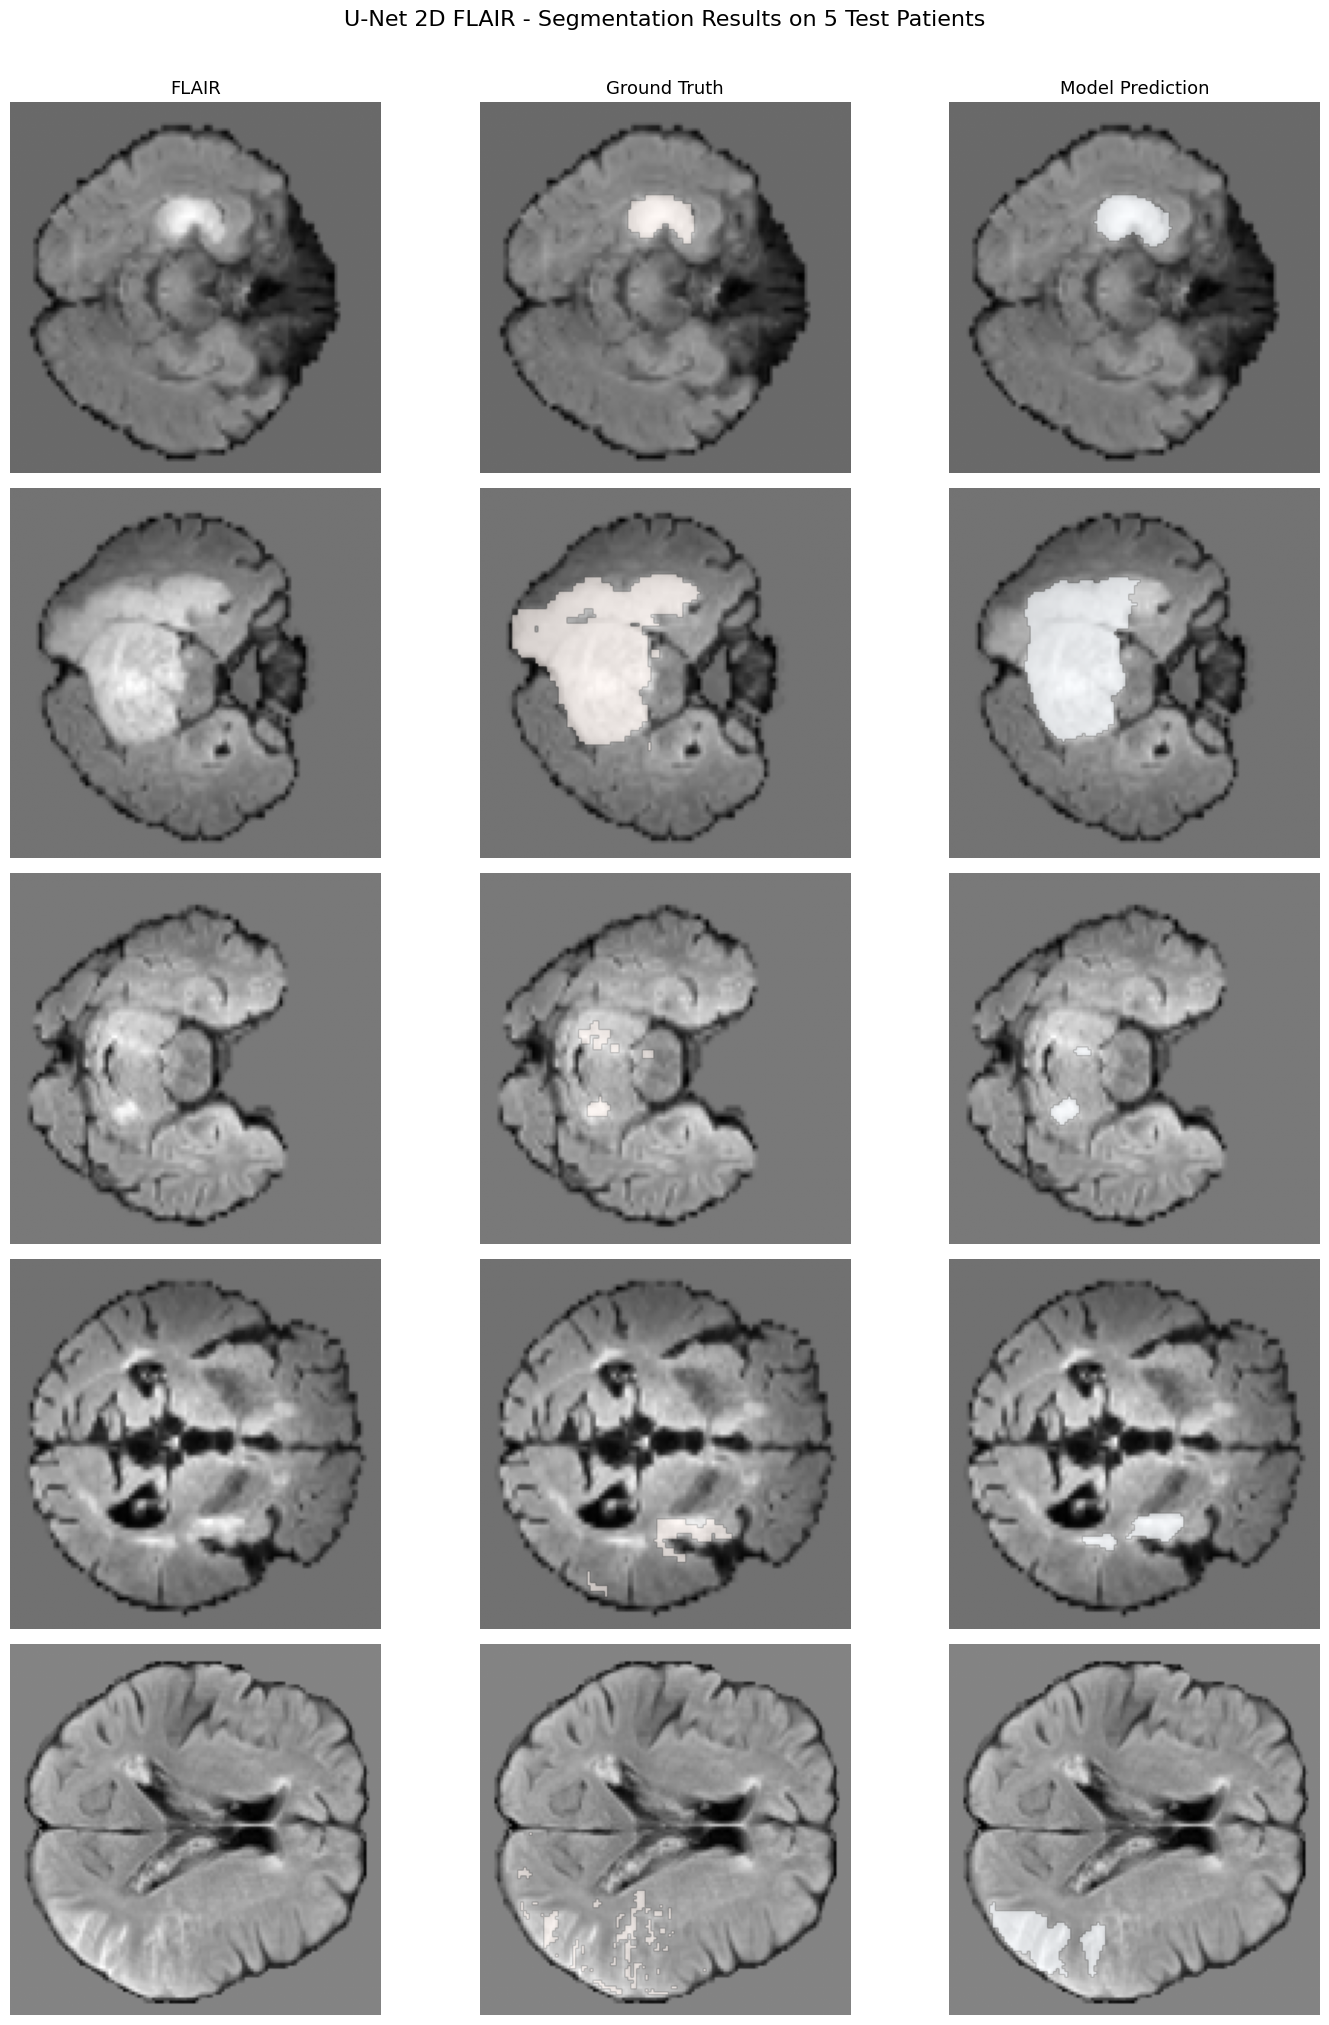

🏃 View run FLAIR_2D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/07484ad364014bfa9a2f44e213a1a5c2
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Segmentation visualization logged to the Best Run.


In [48]:
model.eval()
NUM_PATIENTS_TO_SHOW = 5
selected_patients = test_patients[:NUM_PATIENTS_TO_SHOW]
fig, axes = plt.subplots(NUM_PATIENTS_TO_SHOW, 3, figsize=(15, 4 * NUM_PATIENTS_TO_SHOW))
column_titles = ["FLAIR", "Ground Truth", "Model Prediction"]
for row, patient_dir in enumerate(selected_patients):
    flair = np.load(patient_dir / "flair.npy").astype(np.float32)
    mask = np.load(patient_dir / "mask.npy").astype(np.float32)
    lesion_per_slice = mask.sum(axis=(0, 1))
    slice_idx = np.argmax(lesion_per_slice)
    flair_slice = flair[:, :, slice_idx]
    gt = mask[:, :, slice_idx]
    mean = flair_slice.mean()
    std = flair_slice.std()
    flair_normalized = (flair_slice - mean) / std if std > 0 else flair_slice.copy()
    image_tensor = torch.from_numpy(flair_normalized).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(image_tensor)
        prediction = (torch.sigmoid(output) > 0.5).float().squeeze().cpu().numpy()
    axes[row, 0].imshow(flair_slice, cmap="gray")
    axes[row, 1].imshow(flair_slice, cmap="gray")
    axes[row, 1].imshow(np.ma.masked_where(gt == 0, gt), cmap="Reds", alpha=0.6)
    axes[row, 2].imshow(flair_slice, cmap="gray")
    axes[row, 2].imshow(np.ma.masked_where(prediction == 0, prediction), cmap="Blues", alpha=0.6)
    patient_name = patient_dir.name
    axes[row, 0].set_ylabel(f"{patient_name}\nSlice {slice_idx}", fontsize=10)
    for col in range(3):
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(column_titles[col], fontsize=13)
plt.suptitle("U-Net 2D FLAIR - Segmentation Results on 5 Test Patients", fontsize=16, y=1.01)
plt.tight_layout()
prediction_dir = SAVE_DIR / "mlflow_predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)
segmentation_visualization_path = prediction_dir / "segmentation_visualization.png"
plt.savefig(segmentation_visualization_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_artifact(str(segmentation_visualization_path), artifact_path="predictions")
print("Segmentation visualization logged to the Best Run.")

# Experiment 2: 2D U-Net for Stroke Lesion Segmentation Using the DWI Modality

### configuration

In [49]:
from pathlib import Path
import random
import numpy as np
import torch
DATASET_PATH = Path("/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed")
BATCH_SIZE = 16
NUM_EPOCHS = 100
NUM_WORKERS = 2
MODALITY = "dwi"
NUM_CHANNELS = 1
experiments = [
    {"name": "DWI_2D_Adam_lr1e3", "optimizer": Adam, "lr": 1e-3},
    {"name": "DWI_2D_Adam_lr5e4_DWI", "optimizer": Adam, "lr": 5e-4}
]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = Path("/kaggle/working/models/unet2d_dwi")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("U-Net 2D DWI - Project Configuration")
print(f"Dataset Path : {DATASET_PATH}")
print(f"Modality     : {MODALITY.upper()}")
print(f"Channels     : {NUM_CHANNELS}")
print(f"Device       : {DEVICE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Workers      : {NUM_WORKERS}")
print(f"Experiments  : {len(experiments)}")
print(f"Save Dir     : {SAVE_DIR}")
for exp in experiments:
    print(f"{exp['name']} | LR = {exp['lr']}")

U-Net 2D DWI - Project Configuration
Dataset Path : /kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed
Modality     : DWI
Channels     : 1
Device       : cuda
Batch Size   : 16
Epochs       : 100
Workers      : 2
Experiments  : 2
Save Dir     : /kaggle/working/models/unet2d_dwi
DWI_2D_Adam_lr1e3 | LR = 0.001
DWI_2D_Adam_lr5e4_DWI | LR = 0.0005


### Train / Validation / Test Split

In [50]:
# Get all patient folders
patients = sorted(
    [
        patient.name
        for patient in DATASET_PATH.iterdir()
        if patient.is_dir()
    ]
)

print(f"Total Patients : {len(patients)}")


train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

# Convert patient names to full paths

train_patients = [
    DATASET_PATH / p
    for p in train_patients
]

val_patients = [
    DATASET_PATH / p
    for p in val_patients
]

test_patients = [
    DATASET_PATH / p
    for p in test_patients
]


print("\nDataset Split")
print("-" * 40)

print(
    f"Train      : {len(train_patients):3d} patients "
    f"({len(train_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Validation : {len(val_patients):3d} patients "
    f"({len(val_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Test       : {len(test_patients):3d} patients "
    f"({len(test_patients)/len(patients)*100:.1f}%)"
)

Total Patients : 240

Dataset Split
----------------------------------------
Train      : 168 patients (70.0%)
Validation :  36 patients (15.0%)
Test       :  36 patients (15.0%)


### Data Augmentation / Transforms

In [51]:
train_transform = Compose([

    # Random horizontal flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=0
    ),

    # Random vertical flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=1
    ),

    # Random 90-degree rotation
    RandRotate90d(
        keys=["image", "mask"],
        prob=0.5,
        max_k=3
    )
])

print("Training data augmentation configured.")

Training data augmentation configured.


### Création du StrokeDataset

In [53]:
class StrokeDataset2D(Dataset):

    def __init__(self, patient_dirs, transform=None):

        self.samples = []
        self.transform = transform

        # Build the list of all 2D slices

        for patient_dir in patient_dirs:

            # Load DWI only to determine the number of slices
            dwi = np.load(
                patient_dir / "dwi.npy",
                mmap_mode="r"
            )

            num_slices = dwi.shape[-1]

            for slice_idx in range(num_slices):

                self.samples.append(
                    (patient_dir, slice_idx)
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        patient_dir, slice_idx = self.samples[index]

        # Load DWI volume and Ground Truth mask

        dwi = np.load(
            patient_dir / "dwi.npy",
            mmap_mode="r"
        ).astype(np.float32)

        mask = np.load(
            patient_dir / "mask.npy",
            mmap_mode="r"
        ).astype(np.float32)

        # Extract 2D slice

        image = dwi[:, :, slice_idx]
        target = mask[:, :, slice_idx]

        # Z-score Normalization

        mean = image.mean()
        std = image.std()

        if std > 0:
            image = (image - mean) / std

        image = np.expand_dims(
            image,
            axis=0
        )

        target = np.expand_dims(
            target,
            axis=0
        )

        # Convert to PyTorch tensors

        image = torch.from_numpy(image).float()
        target = torch.from_numpy(target).float()

        if self.transform is not None:

            data = {
                "image": image,
                "mask": target
            }

            data = self.transform(data)

            image = data["image"]
            target = data["mask"]

        return image, target

### Create Datasets and DataLoaders - DWI

In [54]:
# Create Datasets

# Training dataset WITH data augmentation
train_dataset = StrokeDataset2D(
    train_patients,
    transform=train_transform
)

# Validation dataset WITHOUT data augmentation
val_dataset = StrokeDataset2D(
    val_patients,
    transform=None
)

# Test dataset WITHOUT data augmentation
test_dataset = StrokeDataset2D(
    test_patients,
    transform=None
)

# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


print("=" * 60)
print("Dataset Statistics - DWI")
print("=" * 60)

print(f"Training slices   : {len(train_dataset)}")
print(f"Validation slices : {len(val_dataset)}")
print(f"Test slices       : {len(test_dataset)}")

print()

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

print("=" * 60)


images, masks = next(iter(train_loader))

print("\nBatch Verification")
print("-" * 40)

print(f"Input shape : {images.shape}")
print(f"Mask shape  : {masks.shape}")

Dataset Statistics - DWI
Training slices   : 10752
Validation slices : 2304
Test slices       : 2304

Train batches      : 672
Validation batches : 144
Test batches       : 144

Batch Verification
----------------------------------------
Input shape : torch.Size([16, 1, 128, 128])
Mask shape  : torch.Size([16, 1, 128, 128])


### Définir la Loss et l'Optimizer

In [55]:
# Loss Function

loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean",
    lambda_ce=0.5,
    lambda_dice=1.5
)

# Evaluation Metrics

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

iou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)

# Display Configuration

print("=" * 60)
print("Loss Function and Evaluation Metrics - DWI")
print("=" * 60)

print("\nLoss Function")
print(loss_function)

print("\nEvaluation Metrics")
print("- Dice Score")
print("- Mean IoU")

print("\nExperiments")

for exp in experiments:
    print(
        f"{exp['name']} | LR = {exp['lr']}"
    )

print("=" * 60)

Loss Function and Evaluation Metrics - DWI

Loss Function
DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)

Evaluation Metrics
- Dice Score
- Mean IoU

Experiments
DWI_2D_Adam_lr1e3 | LR = 0.001
DWI_2D_Adam_lr5e4_DWI | LR = 0.0005


In [56]:
# Post-processing for predictions

post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5)
])

### Fonction d'entraînement

In [57]:
def train_one_epoch(
    model,
    train_loader,
    optimizer,
    loss_function,
    device
):

    # Set model to training mode
    model.train()

    # Initialize cumulative loss
    epoch_loss = 0.0

    # Iterate over training batches
    for images, masks in train_loader:

        # Move data to device
        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = loss_function(
            outputs,
            masks
        )

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate batch loss
        epoch_loss += loss.item()

    # Average loss over all training batches
    epoch_loss /= len(train_loader)

    return epoch_loss

### Fonction de validation

In [58]:
from monai.metrics import MeanIoU

def validate(model, val_loader, dice_metric, iou_metric, post_pred, device):

    # Set the model to evaluation mode
    model.eval()

    # Reset metrics before validation
    dice_metric.reset()
    iou_metric.reset()

    # Disable gradient computation to save memory and speed up inference
    with torch.no_grad():

        # Iterate over the validation dataset
        for images, masks in val_loader:

            # Move data to the selected device
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)

            # Apply post-processing:
            # 1. Sigmoid activation
            # 2. Threshold at 0.5 to obtain binary masks
            outputs = [
                post_pred(pred)
                for pred in decollate_batch(outputs)
            ]

            # Convert batch of masks into a list
            masks = decollate_batch(masks)

            # Update Dice metric
            dice_metric(
                y_pred=outputs,
                y=masks
            )

            # Update IoU metric
            iou_metric(
                y_pred=outputs,
                y=masks
            )

    # Compute the final metrics over the entire validation set
    dice = dice_metric.aggregate().item()
    iou = iou_metric.aggregate().item()

    # Reset metrics for the next validation epoch
    dice_metric.reset()
    iou_metric.reset()

    return dice, iou

### U-Net 2D DWI - Training Experiments

In [59]:
results = []
DWI_SAVE_DIR = SAVE_DIR / "dwi"
DWI_SAVE_DIR.mkdir(parents=True, exist_ok=True)
for exp in experiments:
    run_name = exp["name"]
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("experiment_group", "DWI-2D")
        mlflow.set_tag("modality", "DWI")
        mlflow.set_tag("dimension", "2D")
        mlflow.set_tag("dataset", "ISLES2022")
        mlflow.set_tag("framework", "PyTorch + MONAI")
        mlflow.set_tag("task", "ischemic_stroke_lesion_segmentation")
        mlflow.log_params({
            "architecture": "U-Net",
            "model": "MONAI UNet",
            "spatial_dims": 2,
            "in_channels": NUM_CHANNELS,
            "out_channels": 1,
            "channels": str((16, 32, 64, 128, 256)),
            "strides": str((2, 2, 2, 2)),
            "num_res_units": 2,
            "optimizer": exp["optimizer"].__name__,
            "learning_rate": exp["lr"],
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "num_workers": NUM_WORKERS,
            "scheduler": "CosineAnnealingLR",
            "loss_function": "DiceCELoss",
            "loss_lambda_ce": 0.5,
            "loss_lambda_dice": 1.5,
            "dice_include_background": False,
            "iou_include_background": False,
            "augmentation": "RandFlipd + RandRotate90d",
            "seed": SEED
        })
        print("\n" + "=" * 60)
        print(f"Experiment: {run_name}")
        print(f"MLflow Run ID: {run.info.run_id}")
        print("=" * 60)
        model = UNet(
            spatial_dims=2,
            in_channels=NUM_CHANNELS,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2
        ).to(DEVICE)
        optimizer = exp["optimizer"](
            model.parameters(),
            lr=exp["lr"]
        )
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS
        )
        best_dice = 0.0
        best_iou = 0.0
        best_epoch = 0
        train_losses = []
        val_dices = []
        val_ious = []
        model_path = DWI_SAVE_DIR / f"best_model_{exp['name']}.pth"
        for epoch in range(NUM_EPOCHS):
            epoch_loss = train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                loss_function=loss_function,
                device=DEVICE
            )
            train_losses.append(epoch_loss)
            dice, iou = validate(
                model=model,
                val_loader=val_loader,
                dice_metric=dice_metric,
                iou_metric=iou_metric,
                post_pred=post_pred,
                device=DEVICE
            )
            val_dices.append(dice)
            val_ious.append(iou)
            scheduler.step()
            mlflow.log_metric("train_loss", epoch_loss, step=epoch + 1)
            mlflow.log_metric("val_dice", dice, step=epoch + 1)
            mlflow.log_metric("val_iou", iou, step=epoch + 1)
            if dice > best_dice:
                best_dice = dice
                best_iou = iou
                best_epoch = epoch + 1
                torch.save(model.state_dict(), model_path)
            print(
                f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f}"
            )
        mlflow.log_metric("best_dice", best_dice)
        mlflow.log_metric("best_iou", best_iou)
        mlflow.log_metric("best_epoch", best_epoch)
        mlflow.log_artifact(str(model_path), artifact_path="model")
        curve_dir = SAVE_DIR / "mlflow_curves"
        curve_dir.mkdir(parents=True, exist_ok=True)
        curve_path = curve_dir / f"training_curves_{exp['name']}.png"
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        epochs = range(1, NUM_EPOCHS + 1)
        axes[0].plot(epochs, train_losses)
        axes[0].set_title("Training Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True)
        axes[1].plot(epochs, val_dices)
        axes[1].set_title("Validation Dice")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Dice")
        axes[1].set_ylim(0, 1)
        axes[1].grid(True)
        axes[2].plot(epochs, val_ious)
        axes[2].set_title("Validation IoU")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("IoU")
        axes[2].set_ylim(0, 1)
        axes[2].grid(True)
        plt.tight_layout()
        plt.savefig(curve_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(str(curve_path), artifact_path="plots")
        run_id = run.info.run_id
        results.append({
            "Experiment": run_name,
            "Run Name": run_name,
            "MLflow Run ID": run_id,
            "Learning Rate": exp["lr"],
            "Best Dice": best_dice,
            "Best IoU": best_iou,
            "Best Epoch": best_epoch,
            "Train Loss": train_losses,
            "Validation Dice": val_dices,
            "Validation IoU": val_ious,
            "Model Path": str(model_path)
        })
        print(
            f"[FIN] {run_name} | Best Dice: {best_dice:.4f} | "
            f"Best IoU: {best_iou:.4f} | Best Epoch: {best_epoch} | "
            f"MLflow Run ID: {run_id}"
        )
print("\nDWI training completed successfully.")


Experiment: DWI_2D_Adam_lr1e3
MLflow Run ID: 6582d83996f947b0a4474810582786dc
Epoch [001/100] | Loss: 1.7296 | Dice: 0.4110 | IoU: 0.3024
Epoch [002/100] | Loss: 1.4393 | Dice: 0.5605 | IoU: 0.4428
Epoch [003/100] | Loss: 1.2348 | Dice: 0.5835 | IoU: 0.4681
Epoch [004/100] | Loss: 1.2184 | Dice: 0.5805 | IoU: 0.4674
Epoch [005/100] | Loss: 1.2097 | Dice: 0.6145 | IoU: 0.4996
Epoch [006/100] | Loss: 1.2031 | Dice: 0.6065 | IoU: 0.4932
Epoch [007/100] | Loss: 1.1992 | Dice: 0.6147 | IoU: 0.5012
Epoch [008/100] | Loss: 1.1971 | Dice: 0.6159 | IoU: 0.4995
Epoch [009/100] | Loss: 1.1940 | Dice: 0.6233 | IoU: 0.5068
Epoch [010/100] | Loss: 1.1909 | Dice: 0.6331 | IoU: 0.5173
Epoch [011/100] | Loss: 1.1877 | Dice: 0.6197 | IoU: 0.5031
Epoch [012/100] | Loss: 1.1875 | Dice: 0.6339 | IoU: 0.5158
Epoch [013/100] | Loss: 1.1851 | Dice: 0.6396 | IoU: 0.5210
Epoch [014/100] | Loss: 1.1843 | Dice: 0.6338 | IoU: 0.5165
Epoch [015/100] | Loss: 1.1819 | Dice: 0.6330 | IoU: 0.5170
Epoch [016/100] | Los

MlflowException: API request to https://elated-autistic-subfloor.ngrok-free.dev/api/2.0/mlflow-artifacts/artifacts/1/6582d83996f947b0a4474810582786dc/artifacts/model/best_model_DWI_2D_Adam_lr1e3.pth failed with exception HTTPSConnectionPool(host='elated-autistic-subfloor.ngrok-free.dev', port=443): Max retries exceeded with url: /api/2.0/mlflow-artifacts/artifacts/1/6582d83996f947b0a4474810582786dc/artifacts/model/best_model_DWI_2D_Adam_lr1e3.pth (Caused by ReadTimeoutError("HTTPSConnectionPool(host='elated-autistic-subfloor.ngrok-free.dev', port=443): Read timed out. (read timeout=120)"))

In [60]:
print(model_path)
print(model_path.exists())
print(f"Model size: {model_path.stat().st_size / (1024 ** 2):.2f} MB")

/kaggle/working/models/unet2d_dwi/dwi/best_model_DWI_2D_Adam_lr1e3.pth
True
Model size: 6.23 MB


In [ ]:
results = []
DWI_SAVE_DIR = SAVE_DIR / "dwi"
DWI_SAVE_DIR.mkdir(parents=True, exist_ok=True)
for exp in experiments:
    run_name = exp["name"]
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("experiment_group", "DWI-2D")
        mlflow.set_tag("modality", "DWI")
        mlflow.set_tag("dimension", "2D")
        mlflow.set_tag("dataset", "ISLES2022")
        mlflow.set_tag("framework", "PyTorch + MONAI")
        mlflow.set_tag("task", "ischemic_stroke_lesion_segmentation")
        mlflow.log_params({
            "architecture": "U-Net",
            "model": "MONAI UNet",
            "spatial_dims": 2,
            "in_channels": NUM_CHANNELS,
            "out_channels": 1,
            "channels": str((16, 32, 64, 128, 256)),
            "strides": str((2, 2, 2, 2)),
            "num_res_units": 2,
            "optimizer": exp["optimizer"].__name__,
            "learning_rate": exp["lr"],
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "num_workers": NUM_WORKERS,
            "scheduler": "CosineAnnealingLR",
            "loss_function": "DiceCELoss",
            "loss_lambda_ce": 0.5,
            "loss_lambda_dice": 1.5,
            "dice_include_background": False,
            "iou_include_background": False,
            "augmentation": "RandFlipd + RandRotate90d",
            "seed": SEED
        })
        print("\n" + "=" * 60)
        print(f"Experiment: {run_name}")
        print(f"MLflow Run ID: {run.info.run_id}")
        print("=" * 60)
        model = UNet(
            spatial_dims=2,
            in_channels=NUM_CHANNELS,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2
        ).to(DEVICE)
        optimizer = exp["optimizer"](
            model.parameters(),
            lr=exp["lr"]
        )
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS
        )
        best_dice = 0.0
        best_iou = 0.0
        best_epoch = 0
        train_losses = []
        val_dices = []
        val_ious = []
        model_path = DWI_SAVE_DIR / f"best_model_{exp['name']}.pth"
        for epoch in range(NUM_EPOCHS):
            epoch_loss = train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                loss_function=loss_function,
                device=DEVICE
            )
            train_losses.append(epoch_loss)
            dice, iou = validate(
                model=model,
                val_loader=val_loader,
                dice_metric=dice_metric,
                iou_metric=iou_metric,
                post_pred=post_pred,
                device=DEVICE
            )
            val_dices.append(dice)
            val_ious.append(iou)
            scheduler.step()
            mlflow.log_metric("train_loss", epoch_loss, step=epoch + 1)
            mlflow.log_metric("val_dice", dice, step=epoch + 1)
            mlflow.log_metric("val_iou", iou, step=epoch + 1)
            if dice > best_dice:
                best_dice = dice
                best_iou = iou
                best_epoch = epoch + 1
                torch.save(model.state_dict(), model_path)
            print(
                f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f}"
            )
        mlflow.log_metric("best_dice", best_dice)
        mlflow.log_metric("best_iou", best_iou)
        mlflow.log_metric("best_epoch", best_epoch)
        mlflow.log_artifact(str(model_path), artifact_path="model")
        curve_dir = SAVE_DIR / "mlflow_curves"
        curve_dir.mkdir(parents=True, exist_ok=True)
        curve_path = curve_dir / f"training_curves_{exp['name']}.png"
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        epochs = range(1, NUM_EPOCHS + 1)
        axes[0].plot(epochs, train_losses)
        axes[0].set_title("Training Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True)
        axes[1].plot(epochs, val_dices)
        axes[1].set_title("Validation Dice")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Dice")
        axes[1].set_ylim(0, 1)
        axes[1].grid(True)
        axes[2].plot(epochs, val_ious)
        axes[2].set_title("Validation IoU")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("IoU")
        axes[2].set_ylim(0, 1)
        axes[2].grid(True)
        plt.tight_layout()
        plt.savefig(curve_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(str(curve_path), artifact_path="plots")
        run_id = run.info.run_id
        results.append({
            "Experiment": run_name,
            "Run Name": run_name,
            "MLflow Run ID": run_id,
            "Learning Rate": exp["lr"],
            "Best Dice": best_dice,
            "Best IoU": best_iou,
            "Best Epoch": best_epoch,
            "Train Loss": train_losses,
            "Validation Dice": val_dices,
            "Validation IoU": val_ious,
            "Model Path": str(model_path)
        })
        print(
            f"[FIN] {run_name} | Best Dice: {best_dice:.4f} | "
            f"Best IoU: {best_iou:.4f} | Best Epoch: {best_epoch} | "
            f"MLflow Run ID: {run_id}"
        )
print("\nDWI training completed successfully.")

### Tracer les courbes de Loss et du Dice

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for result in results:
    epochs = range(1, len(result["Train Loss"]) + 1)
    plt.plot(epochs, result["Train Loss"], label=result["Experiment"])
plt.title("U-Net 2D DWI - Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
for result in results:
    epochs = range(1, len(result["Validation Dice"]) + 1)
    plt.plot(epochs, result["Validation Dice"], label=result["Experiment"])
plt.title("U-Net 2D DWI - Validation Dice Comparison")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Load the Best DWI Model

In [ ]:
best_result = max(results, key=lambda x: x["Best Dice"])
print("Best Experiment :", best_result["Experiment"])
print("Best Dice       :", f"{best_result['Best Dice']:.4f}")
print("Best IoU        :", f"{best_result['Best IoU']:.4f}")
print("Best Epoch      :", best_result["Best Epoch"])
print("Model Path      :", best_result["Model Path"])
print("MLflow Run ID   :", best_result["MLflow Run ID"])
model = UNet(
    spatial_dims=2,
    in_channels=NUM_CHANNELS,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
).to(DEVICE)
model.load_state_dict(
    torch.load(
        best_result["Model Path"],
        map_location=DEVICE
    )
)
model.eval()
print("Best DWI model loaded successfully.")

### Evaluate the Best DWI Model

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
model.eval()
dice_metric.reset()
iou_metric.reset()
all_predictions = []
all_masks = []
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        outputs = model(images)
        predictions = (torch.sigmoid(outputs) > 0.5).float()
        dice_metric(y_pred=predictions, y=masks)
        iou_metric(y_pred=predictions, y=masks)
        all_predictions.append(predictions.cpu().numpy().ravel())
        all_masks.append(masks.cpu().numpy().ravel())
dice = dice_metric.aggregate().item()
iou = iou_metric.aggregate().item()
dice_metric.reset()
iou_metric.reset()
all_predictions = np.concatenate(all_predictions).astype(np.uint8)
all_masks = np.concatenate(all_masks).astype(np.uint8)
precision = precision_score(all_masks, all_predictions, zero_division=0)
recall = recall_score(all_masks, all_predictions, zero_division=0)
f1 = f1_score(all_masks, all_predictions, zero_division=0)
cm = confusion_matrix(all_masks, all_predictions, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
results_metrics = pd.DataFrame({
    "Metric": ["Dice", "IoU", "Precision", "Recall", "F1-score"],
    "Value": [dice, iou, precision, recall, f1]
})
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_metric("test_dice", dice)
    mlflow.log_metric("test_iou", iou)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_f1", f1)
    mlflow.set_tag("evaluation_status", "test_evaluated")
print("U-Net 2D DWI - Test Set Performance")
display(results_metrics)
print("\nConfusion Matrix")
print(cm)
print("\nPixel Classification")
print(f"TP : {tp}")
print(f"TN : {tn}")
print(f"FP : {fp}")
print(f"FN : {fn}")

### Evaluation Charts

In [ ]:
evaluation_dir = SAVE_DIR / "mlflow_evaluation"
evaluation_dir.mkdir(parents=True, exist_ok=True)
test_metrics_path = evaluation_dir / "test_metrics.png"
confusion_matrix_path = evaluation_dir / "confusion_matrix.png"
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results_metrics["Metric"], results_metrics["Value"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("DWI Model - Test Metrics")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}", ha="center")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig(test_metrics_path, dpi=150, bbox_inches="tight")
plt.close(fig)
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Stroke"]
)
disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix - DWI Model")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.close(fig)
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_artifact(str(test_metrics_path), artifact_path="evaluation")
    mlflow.log_artifact(str(confusion_matrix_path), artifact_path="evaluation")
print("Evaluation artifacts saved and logged to the Best DWI Run.")

### Confusion Matrix

In [ ]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        all_predictions.extend(
            predictions.cpu().numpy().flatten().astype(np.uint8)
        )

        all_targets.extend(
            masks.cpu().numpy().flatten().astype(np.uint8)
        )

# Compute confusion matrix
cm = confusion_matrix(
    all_targets,
    all_predictions
)

tn, fp, fn, tp = cm.ravel()

print("=" * 50)
print("Confusion Matrix")
print("=" * 50)

print(cm)

print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Stroke"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Confusion Matrix - DWI Model")

plt.show()

### Visualize DWI Segmentation

In [ ]:
model.eval()
NUM_PATIENTS_TO_SHOW = 5
selected_patients = test_patients[:NUM_PATIENTS_TO_SHOW]
fig, axes = plt.subplots(NUM_PATIENTS_TO_SHOW, 3, figsize=(15, 4 * NUM_PATIENTS_TO_SHOW))
column_titles = ["DWI", "Ground Truth", "Model Prediction"]
for row, patient_dir in enumerate(selected_patients):
    dwi = np.load(patient_dir / "dwi.npy").astype(np.float32)
    mask = np.load(patient_dir / "mask.npy").astype(np.float32)
    lesion_per_slice = mask.sum(axis=(0, 1))
    slice_idx = np.argmax(lesion_per_slice)
    dwi_slice = dwi[:, :, slice_idx]
    gt = mask[:, :, slice_idx]
    mean = dwi_slice.mean()
    std = dwi_slice.std()
    dwi_normalized = (dwi_slice - mean) / std if std > 0 else dwi_slice.copy()
    image_tensor = torch.from_numpy(dwi_normalized).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(image_tensor)
        prediction = (torch.sigmoid(output) > 0.5).float().squeeze().cpu().numpy()
    axes[row, 0].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(np.ma.masked_where(gt == 0, gt), cmap="Reds", alpha=0.6)
    axes[row, 2].imshow(dwi_slice, cmap="gray")
    axes[row, 2].imshow(np.ma.masked_where(prediction == 0, prediction), cmap="Blues", alpha=0.6)
    patient_name = patient_dir.name
    axes[row, 0].set_ylabel(f"{patient_name}\nSlice {slice_idx}", fontsize=10)
    for col in range(3):
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(column_titles[col], fontsize=13)
plt.suptitle("U-Net 2D DWI - Segmentation Results on 5 Test Patients", fontsize=16, y=1.01)
plt.tight_layout()
prediction_dir = SAVE_DIR / "mlflow_predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)
segmentation_visualization_path = prediction_dir / "segmentation_visualization.png"
plt.savefig(segmentation_visualization_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_artifact(str(segmentation_visualization_path), artifact_path="predictions")
print("DWI segmentation visualization logged to the Best Run.")

In [ ]:
model.eval()
NUM_PATIENTS_TO_SHOW = 5
selected_patients = test_patients[:NUM_PATIENTS_TO_SHOW]
fig, axes = plt.subplots(NUM_PATIENTS_TO_SHOW, 3, figsize=(15, 4 * NUM_PATIENTS_TO_SHOW))
column_titles = ["DWI", "Ground Truth", "Model Prediction"]
for row, patient_dir in enumerate(selected_patients):
    dwi = np.load(patient_dir / "dwi.npy").astype(np.float32)
    mask = np.load(patient_dir / "mask.npy").astype(np.float32)
    lesion_per_slice = mask.sum(axis=(0, 1))
    slice_idx = np.argmax(lesion_per_slice)
    dwi_slice = dwi[:, :, slice_idx]
    gt = mask[:, :, slice_idx]
    mean = dwi_slice.mean()
    std = dwi_slice.std()
    dwi_normalized = (dwi_slice - mean) / std if std > 0 else dwi_slice.copy()
    image_tensor = torch.from_numpy(dwi_normalized).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(image_tensor)
        prediction = (torch.sigmoid(output) > 0.5).float().squeeze().cpu().numpy()
    axes[row, 0].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(np.ma.masked_where(gt == 0, gt), cmap="Reds", alpha=0.6)
    axes[row, 2].imshow(dwi_slice, cmap="gray")
    axes[row, 2].imshow(np.ma.masked_where(prediction == 0, prediction), cmap="Blues", alpha=0.6)
    patient_name = patient_dir.name
    axes[row, 0].set_ylabel(f"{patient_name}\nSlice {slice_idx}", fontsize=10)
    for col in range(3):
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(column_titles[col], fontsize=13)
plt.suptitle("U-Net 2D DWI - Segmentation Results on 5 Test Patients", fontsize=16, y=1.01)
plt.tight_layout()
prediction_dir = SAVE_DIR / "mlflow_predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)
segmentation_visualization_path = prediction_dir / "segmentation_visualization.png"
plt.savefig(segmentation_visualization_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_artifact(str(segmentation_visualization_path), artifact_path="predictions")
print("DWI segmentation visualization logged to the Best Run.")